# Cross-sectional analyses

Consolidated notebook for the Liu (2025) cross-sectional recreation. Single source for the three locked measures: peak distance, sum-selectivity, distinctiveness.

**Sample:** 22 OTC patients (11 LH-intact, 11 RH-intact), 38 controls. nonOTC excluded. sub-017 excluded.

## 1. Setup

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import t as tdist
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

BASE    = Path(processed_dir)
LIU_CSV = Path('/user_data/csimmon2/git_repos/sym_pt/D_liu/liu_exact_replication_v2.csv')
FIG_DIR = Path('/user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact')
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXCLUDE     = ['sub-017']
EXCLUDE_SES = [('sub-108', 2)]
LIU_CODES   = {'sub-004': 'UD', 'sub-021': 'TC', 'sub-007': 'OT',
               'sub-044': 'SN', 'sub-099': 'KN'}

# Build SUB_CODES from sub_info.csv: code if available, else sub-XXX number
_info_df = pd.read_csv('/user_data/csimmon2/git_repos/sym_pt/sub_info.csv')
SUB_CODES = {row['sub']: (row['code'] if pd.notna(row['code']) and row['code'] != '' else row['sub'].replace('sub-', ''))
             for _, row in _info_df.drop_duplicates('sub').iterrows()}

# FDR: 'bh' = Benjamini-Hochberg (liberal); 'by' = Benjamini-Yekutieli (Liu's choice);
# None = disable correction.
FDR_METHOD = 'bh'

plt.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'DejaVu Sans']
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

print(f'LIU_CSV : {LIU_CSV}')
print(f'FIG_DIR : {FIG_DIR}')
print(f'FDR     : {FDR_METHOD}')


LIU_CSV : /user_data/csimmon2/git_repos/sym_pt/D_liu/liu_exact_replication_v2.csv
FIG_DIR : /user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact
FDR     : bh


## 2. Load data

In [3]:
le = pd.read_csv(LIU_CSV)
addon = LIU_CSV.parent / 'liu_exact_replication_v2_IFG_addon.csv'
if addon.exists():
    le = pd.concat([le, pd.read_csv(addon)], ignore_index=True)
    print(f'Merged IFG addon: +{(pd.read_csv(addon)["subject_id"]).nunique()} subj')
le = le[~le['subject_id'].isin(EXCLUDE)]
le['ses_num'] = pd.to_numeric(le['session'], errors='coerce').astype(int)
for bad_sub, bad_ses in EXCLUDE_SES:
    le = le[~((le['subject_id'] == bad_sub) & (le['ses_num'] == bad_ses))]

le_summary = le.drop(columns=['pair', 'fisher_r']).drop_duplicates().copy()

# Controls → first session
ctrl_all = le_summary[le_summary['status'] == 'control']
fs = ctrl_all.groupby('subject_id')['ses_num'].min().reset_index().rename(columns={'ses_num': 'keep'})
ctrl_le = ctrl_all.merge(fs, on='subject_id')
ctrl_le = ctrl_le[ctrl_le['ses_num'] == ctrl_le['keep']].drop(columns='keep')

# OTC patients → last session
pt_all = le_summary[le_summary['group'] == 'OTC']
ls = pt_all.groupby('subject_id')['ses_num'].max().reset_index().rename(columns={'ses_num': 'keep'})
pt_le = pt_all.merge(ls, on='subject_id')
pt_le = pt_le[pt_le['ses_num'] == pt_le['keep']].drop(columns='keep')

# Pairwise: filter le directly, NOT via le_summary
ctrl_pw = le[le['status'] == 'control'].merge(fs, on='subject_id')
ctrl_pw = ctrl_pw[ctrl_pw['ses_num'] == ctrl_pw['keep']].drop(columns='keep')
pt_pw = le[le['group'] == 'OTC'].merge(ls, on='subject_id')
pt_pw = pt_pw[pt_pw['ses_num'] == pt_pw['keep']].drop(columns='keep')

ctrl_subs = sorted(ctrl_le['subject_id'].unique())
otc_subs  = sorted(pt_le['subject_id'].unique())

print(f'Controls: {len(ctrl_subs)}')
print(f'OTC patients: {len(otc_subs)}')
print(f'  Liu overlap: {[s for s in otc_subs if s in LIU_CODES]}')
print(f'ctrl_pw rows: {len(ctrl_pw)}, pt_pw rows: {len(pt_pw)}')

Controls: 38
OTC patients: 22
  Liu overlap: ['sub-004', 'sub-021', 'sub-044', 'sub-099']
ctrl_pw rows: 4636, pt_pw rows: 1342


## 3. Helpers

In [4]:
def crawford(x, c):
    """Crawford & Howell (1998) modified t, returns (t, p)."""
    c = np.asarray(c); c = c[~np.isnan(c)]
    if len(c) < 3 or np.isnan(x): return np.nan, np.nan
    m, sd = c.mean(), c.std(ddof=1)
    if sd == 0: return np.nan, np.nan
    t = (x - m) / (sd * np.sqrt((len(c) + 1) / len(c)))
    p = 2 * (1 - tdist.cdf(abs(t), df=len(c) - 1))
    return t, p

def fisher_z(r):
    r = np.clip(np.asarray(r, float), -0.9999, 0.9999)
    return 0.5 * np.log((1 + r) / (1 - r))

def fdr_correct(p_values, method='bh', alpha=0.05):
    """FDR correction. 'bh' (Benjamini-Hochberg, liberal) or 'by' (Benjamini-Yekutieli).
    Returns boolean mask of significant tests."""
    p = np.asarray(p_values, float)
    valid = ~np.isnan(p)
    p_valid = p[valid]
    n = len(p_valid)
    if n == 0: return np.zeros_like(p, bool)
    order = np.argsort(p_valid)
    ranked = p_valid[order]
    if method == 'bh':
        thresh = np.arange(1, n + 1) / n * alpha
    elif method == 'by':
        c_n = np.sum(1.0 / np.arange(1, n + 1))
        thresh = np.arange(1, n + 1) / (n * c_n) * alpha
    else:
        raise ValueError(f"method must be 'bh' or 'by', got {method!r}")
    passed = ranked <= thresh
    max_idx = np.where(passed)[0].max() if passed.any() else -1
    sig_valid = np.zeros(n, bool)
    if max_idx >= 0:
        sig_valid[order[:max_idx + 1]] = True
    sig = np.zeros_like(p, bool)
    sig[valid] = sig_valid
    return sig

def pt_intact_hemi(sub):
    sd = pt_le[pt_le['subject_id'] == sub]
    if sd.empty: return None
    intact = sd['intact_hemi'].iloc[0]
    return 'l' if intact == 'left' else 'r' if intact == 'right' else None

WORD_CATS = {'word_VWFA', 'word_STG', 'word_pSTG_liu', 'word_IFG'}

## 4. Fig 2C–H — Per-subject ROI peak scatter (native)

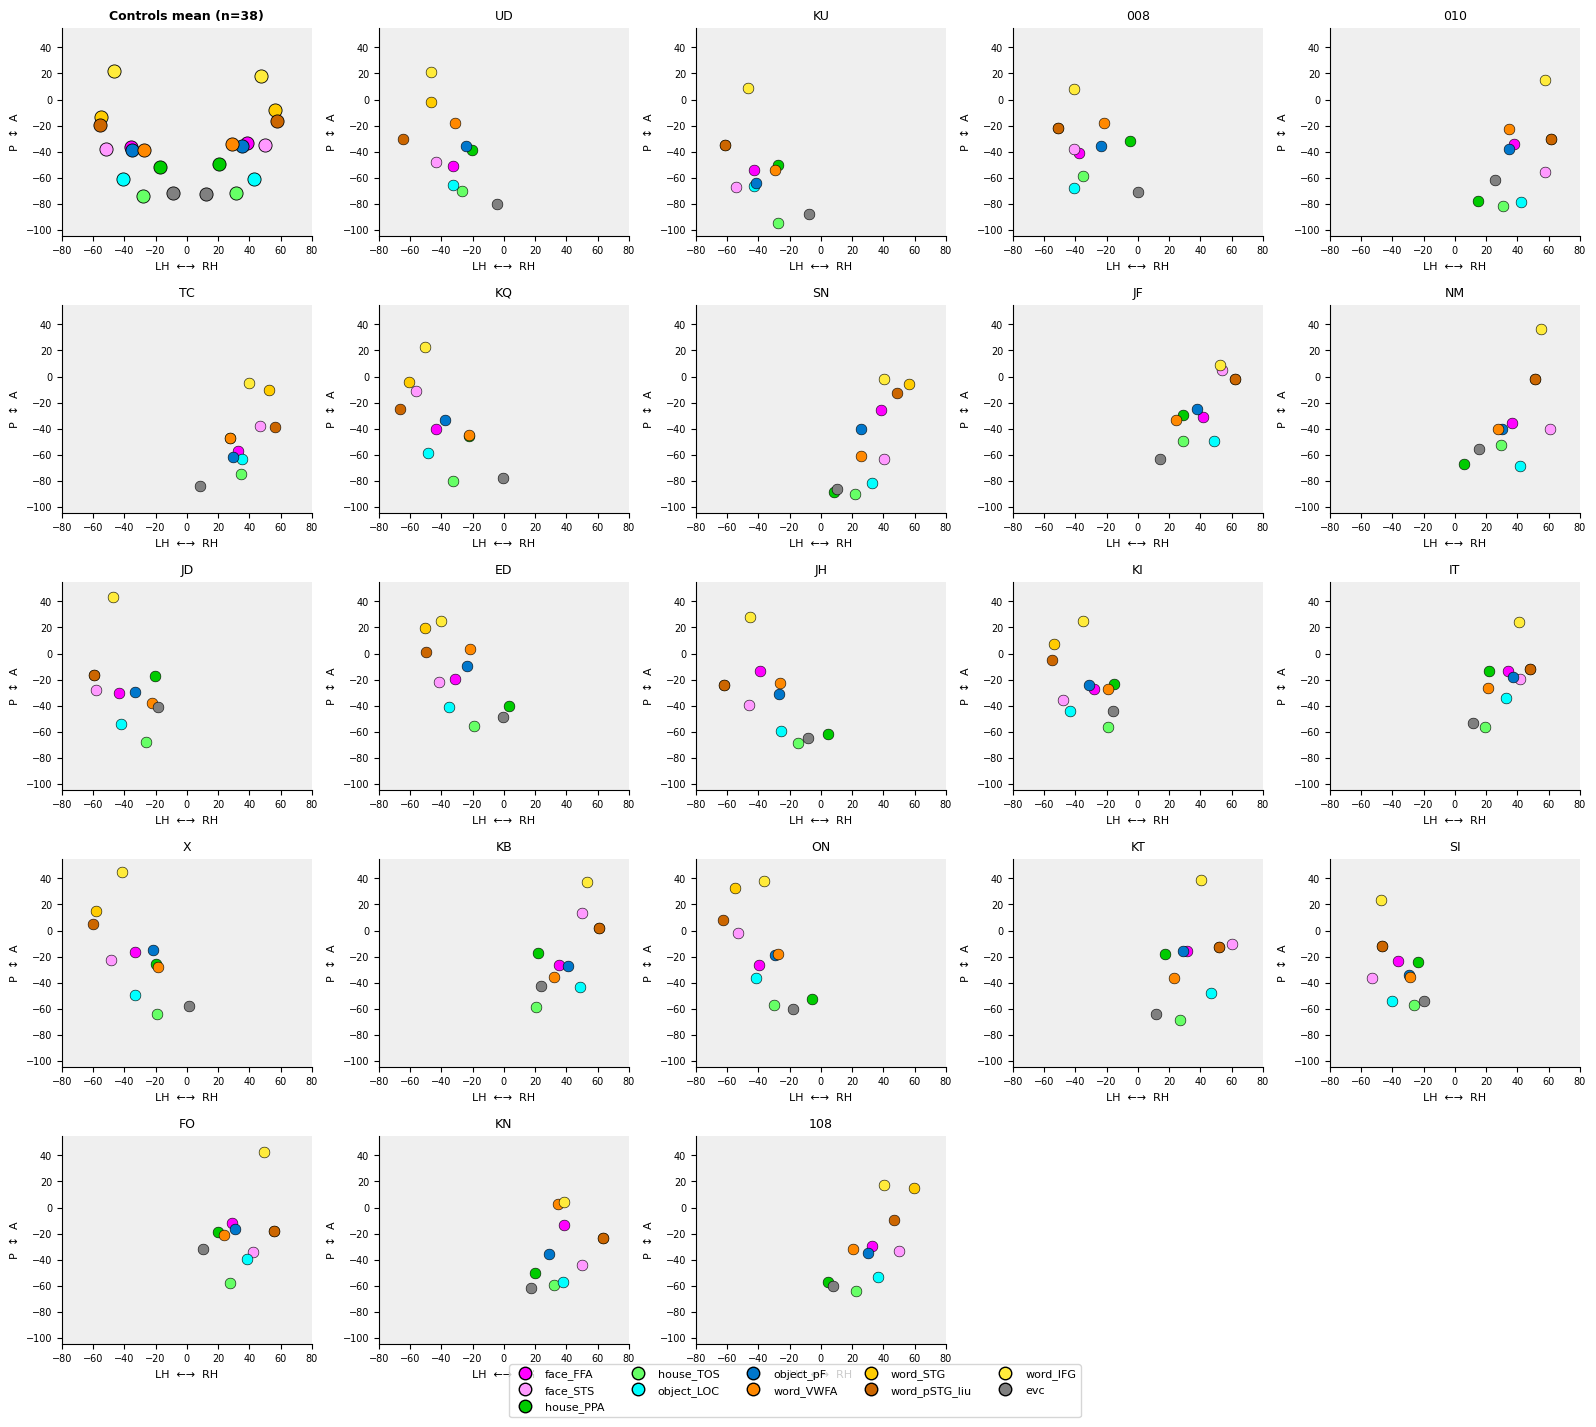

In [5]:
ROI_COLOR = {
    'face_FFA':   'magenta',  'face_STS':    '#ff99ff',
    'house_PPA':  '#00cc00',  'house_TOS':   '#66ff66',
    'object_LOC': 'cyan',     'object_pF':   '#0077cc',
    'word_VWFA':  '#ff8800',  'word_STG':    '#ffcc00',
    'word_pSTG_liu': '#cc6600',
    'word_IFG':   '#ffeb3b',
    'evc':        'gray',
}
ALL_CATS = list(ROI_COLOR.keys())
XLIM = (-80, 80); YLIM = (-105, 55)

def scatter_subject(ax, df, sub, title):
    for cat in ALL_CATS:
        for h in ('l', 'r'):
            m = df[(df['subject_id'] == sub) & (df['category'] == cat) & (df['hemi'] == h)]
            if not len(m): continue
            ax.scatter(m['peak_x_native'].iloc[0], m['peak_y_native'].iloc[0],
                       s=60, c=ROI_COLOR[cat], edgecolors='k', linewidth=0.4)
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
    ax.set_xlabel('LH  \u2190\u2192  RH', fontsize=8)
    ax.set_ylabel('P  \u2195  A', fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.set_facecolor('#efefef'); ax.tick_params(labelsize=7)

n_pt  = len(otc_subs)
n_cols = 5
n_rows = int(np.ceil((n_pt + 1) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 2.8 * n_rows))
axes = axes.flatten()

# Controls mean (per ROI \u00d7 hemi)
ax = axes[0]
for cat in ALL_CATS:
    for h in ('l', 'r'):
        xs, ys = [], []
        for s in ctrl_subs:
            m = ctrl_le[(ctrl_le['subject_id'] == s) & (ctrl_le['category'] == cat) & (ctrl_le['hemi'] == h)]
            if len(m):
                xs.append(m['peak_x_native'].iloc[0]); ys.append(m['peak_y_native'].iloc[0])
        if xs:
            ax.scatter(np.mean(xs), np.mean(ys), s=90, c=ROI_COLOR[cat], edgecolors='k', linewidth=0.6)
ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
ax.set_title(f'Controls mean (n={len(ctrl_subs)})', fontsize=9, fontweight='bold')
ax.set_xlabel('LH  \u2190\u2192  RH', fontsize=8); ax.set_ylabel('P  \u2195  A', fontsize=8)
ax.set_facecolor('#efefef'); ax.tick_params(labelsize=7)

for i, s in enumerate(otc_subs):
    label = SUB_CODES.get(s, s.replace('sub-', ''))
    scatter_subject(axes[i + 1], pt_le, s, label)
for j in range(n_pt + 1, len(axes)):
    axes[j].axis('off')

legend_handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                             markeredgecolor='k', markersize=9, label=cat)
                  for cat, c in ROI_COLOR.items()]
fig.legend(handles=legend_handles, loc='lower center', ncol=5, fontsize=8,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_exact_fig2CH.png', dpi=300, bbox_inches='tight')
plt.show()


## 5. Fig 2I/J — Spatial topography Crawford t (ventral key)

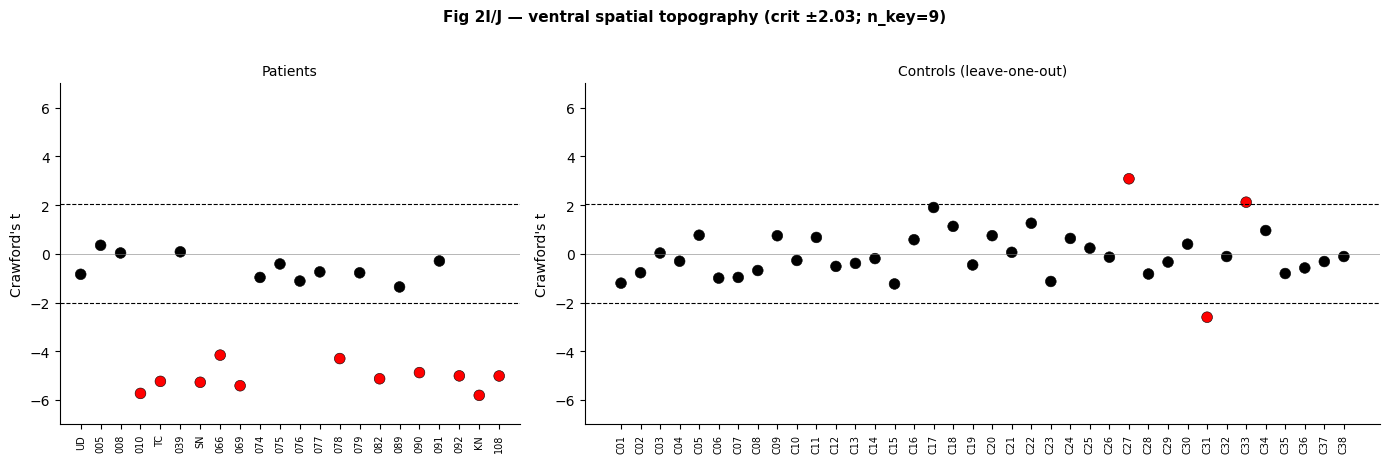

Patient t-values:    {'UD': -0.84, '005': 0.35, '008': 0.03, '010': -5.73, 'TC': -5.24, '039': 0.08, 'SN': -5.28, '066': -4.16, '069': -5.42, '074': -0.97, '075': -0.42, '076': -1.12, '077': -0.74, '078': -4.3, '079': -0.78, '082': -5.13, '089': -1.36, '090': -4.88, '091': -0.3, '092': -5.01, 'KN': -5.81, '108': -5.02}
Control t-range:     [-2.60, 3.08]


In [6]:
VENTRAL_KEY = [('evc',       'l'), ('evc',       'r'),
               ('house_PPA', 'l'), ('house_PPA', 'r'),
               ('object_pF', 'l'), ('object_pF', 'r'),
               ('face_FFA',  'l'), ('face_FFA',  'r'),
               ('word_VWFA', 'PREF')]

def resolve_hemi(hspec, is_ctrl, intact):
    if hspec in ('l', 'r'): return hspec
    if hspec == 'PREF':
        if is_ctrl: return 'l'
        return 'l' if intact == 'left' else 'r' if intact == 'right' else None
    return None

def build_xmat(df, subs, is_ctrl, intact_map):
    X = np.full((len(VENTRAL_KEY), len(subs)), np.nan)
    for i, (cat, hspec) in enumerate(VENTRAL_KEY):
        for j, s in enumerate(subs):
            h = resolve_hemi(hspec, is_ctrl, intact_map.get(s))
            if h is None: continue
            m = df[(df['subject_id'] == s) & (df['category'] == cat) & (df['hemi'] == h)]
            if len(m): X[i, j] = m['peak_x_native'].iloc[0]
    return X

intact_map = dict(zip(le_summary['subject_id'], le_summary['intact_hemi']))
X_ctrl = build_xmat(ctrl_le, ctrl_subs, True, intact_map)
X_pt   = build_xmat(pt_le,   otc_subs,  False, intact_map)
n_ctrl = len(ctrl_subs)

spcor_pt   = np.full(len(otc_subs), np.nan)
null_forpt = np.full((n_ctrl, len(otc_subs)), np.nan)
for p, s in enumerate(otc_subs):
    valid = ~np.isnan(X_pt[:, p])
    if valid.sum() < 3: continue
    pat_vec   = X_pt[valid, p]
    ctrl_sub  = X_ctrl[valid, :]
    mean_ctrl = np.nanmean(ctrl_sub, axis=1)
    ok = ~np.isnan(pat_vec) & ~np.isnan(mean_ctrl)
    if ok.sum() >= 3:
        spcor_pt[p] = np.corrcoef(pat_vec[ok], mean_ctrl[ok])[0, 1]
    for t_idx in range(n_ctrl):
        others = [c for c in range(n_ctrl) if c != t_idx]
        rest   = np.nanmean(ctrl_sub[:, others], axis=1)
        me     = ctrl_sub[:, t_idx]
        ok = ~np.isnan(me) & ~np.isnan(rest)
        if ok.sum() >= 3:
            null_forpt[t_idx, p] = np.corrcoef(me[ok], rest[ok])[0, 1]

spcor_ctrl = np.full(n_ctrl, np.nan)
for c in range(n_ctrl):
    others = [j for j in range(n_ctrl) if j != c]
    rest   = np.nanmean(X_ctrl[:, others], axis=1)
    me     = X_ctrl[:, c]
    ok = ~np.isnan(me) & ~np.isnan(rest)
    if ok.sum() >= 6:
        spcor_ctrl[c] = np.corrcoef(me[ok], rest[ok])[0, 1]

spcor_pt_fz   = fisher_z(spcor_pt)
null_pt_fz    = fisher_z(null_forpt)
spcor_ctrl_fz = fisher_z(spcor_ctrl)

t_pt   = np.array([crawford(spcor_pt_fz[p], null_pt_fz[:, p])[0] for p in range(len(otc_subs))])
t_ctrl = np.array([crawford(spcor_ctrl_fz[c], np.delete(spcor_ctrl_fz, c))[0] for c in range(n_ctrl)])

min_df = max(n_ctrl - 1, 3)
crit_2IJ = float(tdist.ppf(0.975, df=min_df))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5),
                         gridspec_kw={'width_ratios': [len(otc_subs), n_ctrl]})
pt_labels   = [LIU_CODES.get(s, s.replace('sub-', '')) for s in otc_subs]
ctrl_labels = [f'C{i+1:02d}' for i in range(n_ctrl)]

ymax = max(7, int(np.ceil(max(np.nanmax(np.abs(t_pt)), np.nanmax(np.abs(t_ctrl))))) + 1)

for ax, xs, ts, labels, title in [
    (axes[0], np.arange(len(otc_subs)), t_pt, pt_labels, 'Patients'),
    (axes[1], np.arange(n_ctrl), t_ctrl, ctrl_labels, 'Controls (leave-one-out)'),
]:
    colors = ['red' if (not np.isnan(v) and abs(v) > crit_2IJ) else 'black' for v in ts]
    ax.scatter(xs, ts, s=60, c=colors, edgecolors='k', linewidth=0.4)
    ax.axhline( crit_2IJ, color='k', lw=0.8, ls='--')
    ax.axhline(-crit_2IJ, color='k', lw=0.8, ls='--')
    ax.axhline(0, color='gray', lw=0.4)
    ax.set_ylim(-ymax, ymax)
    ax.set_xticks(xs); ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Crawford's t")

plt.suptitle(f'Fig 2I/J — ventral spatial topography (crit ±{crit_2IJ:.2f}; n_key={len(VENTRAL_KEY)})',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_exact_fig2IJ.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Patient t-values:    {dict(zip(pt_labels, t_pt.round(2)))}')
print(f'Control t-range:     [{np.nanmin(t_ctrl):.2f}, {np.nanmax(t_ctrl):.2f}]')

## 6. Peak coordinates (MNI) — controls vs patients

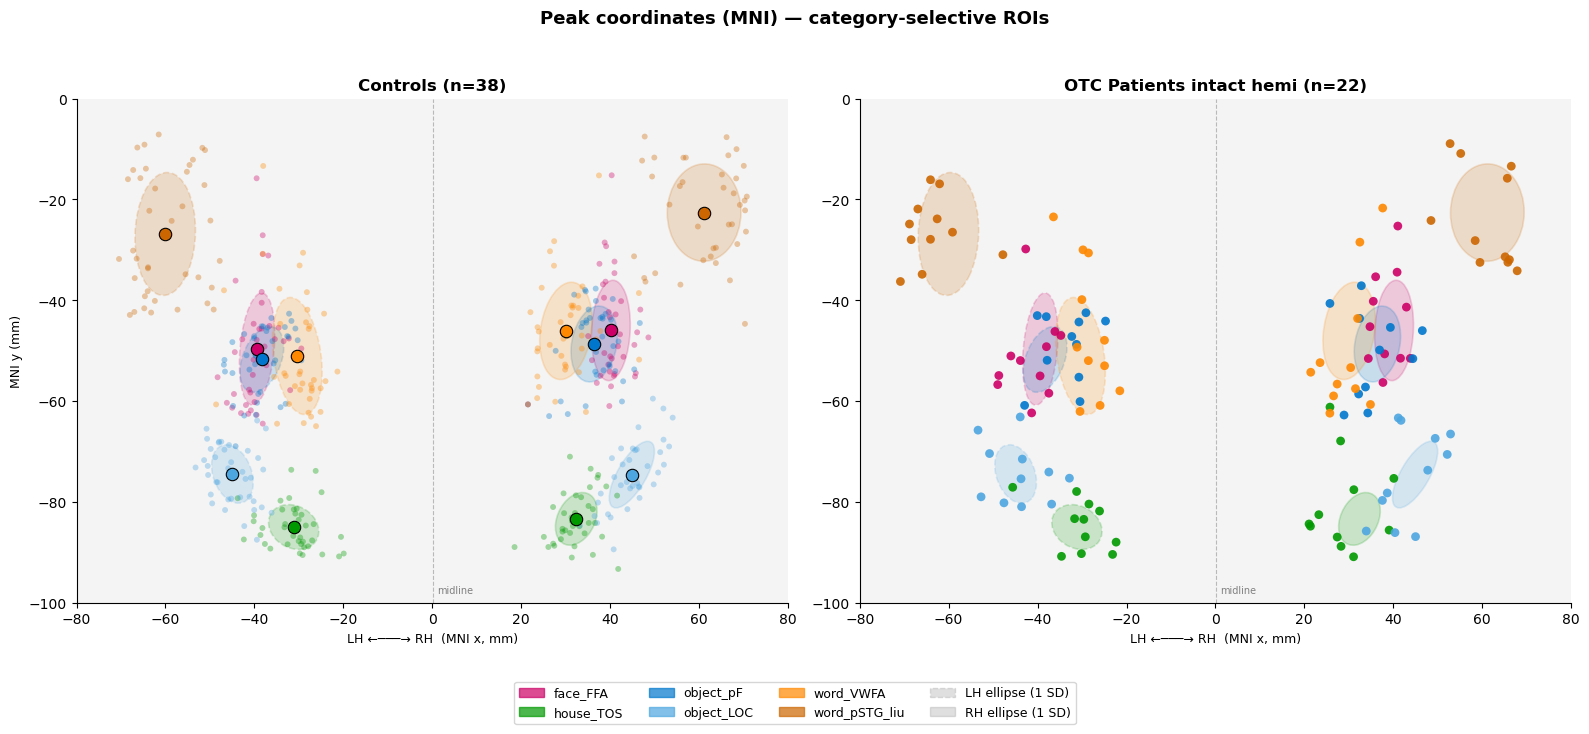

In [7]:
# Peak coordinate scatter (MNI) — Controls (ellipses) | Patients (dots)
# Reads peak_coords_mni.csv produced by calc_peak_coords_mni.py.

from matplotlib.patches import Ellipse
import matplotlib.transforms as mtransforms

MNI_CSV = Path(processed_dir) / 'group_results' / 'peak_coords' / 'peak_coords_mni.csv'

CATS_PEAK = [
    ('face_FFA',      '#cc0066'),
    ('house_TOS',     '#009900'),
    ('object_pF',     '#0077cc'),
    ('object_LOC',    '#4da6e0'),
    ('word_VWFA',     '#ff8800'),
    ('word_pSTG_liu', '#cc6600'),
]

def confidence_ellipse(x, y, ax, n_std=1.0, **kw):
    if len(x) < 3: return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx = np.sqrt(1 + pearson); ry = np.sqrt(1 - pearson)
    e = Ellipse((0, 0), width=2 * rx, height=2 * ry, **kw)
    sx = np.sqrt(cov[0, 0]) * n_std; sy = np.sqrt(cov[1, 1]) * n_std
    t = (mtransforms.Affine2D().rotate_deg(45).scale(sx, sy)
         .translate(np.mean(x), np.mean(y)))
    e.set_transform(t + ax.transData); ax.add_patch(e)


# ── Load + session filter (matches Cell 4) ────────────────────────────────────
mni = pd.read_csv(MNI_CSV)
mni = mni[~mni['subject_id'].isin(EXCLUDE)]
mni['ses_num'] = pd.to_numeric(mni['session'], errors='coerce').astype(int)
for bad_sub, bad_ses in EXCLUDE_SES:
    mni = mni[~((mni['subject_id'] == bad_sub) & (mni['ses_num'] == bad_ses))]

ctrl = mni[mni['status'] == 'control'].copy()
fs   = ctrl.groupby('subject_id')['ses_num'].min().reset_index().rename(columns={'ses_num': 'k'})
ctrl = ctrl.merge(fs, on='subject_id')
ctrl = ctrl[ctrl['ses_num'] == ctrl['k']].drop(columns='k')

pt   = mni[mni['group'] == 'OTC'].copy()
ls   = pt.groupby('subject_id')['ses_num'].max().reset_index().rename(columns={'ses_num': 'k'})
pt   = pt.merge(ls, on='subject_id')
pt   = pt[pt['ses_num'] == pt['k']].drop(columns='k')

ctrl_subs_mni = sorted(ctrl['subject_id'].unique())
pt_subs_mni   = sorted(pt['subject_id'].unique())


def coords(df, sub, roi, h):
    m = df[(df['subject_id'] == sub) & (df['category'] == roi) & (df['hemi'] == h)]
    if len(m) == 0: return None
    x, y = float(m['peak_x_mni'].iloc[0]), float(m['peak_y_mni'].iloc[0])
    return None if (np.isnan(x) or np.isnan(y)) else (x, y)


def intact(sub):
    m = pt[pt['subject_id'] == sub]
    return None if m.empty else ('l' if m['intact_hemi'].iloc[0] == 'left' else 'r')


# Limits + midline
xlim = (-80, 80)
ylim = (-100, 0)
lx = ctrl[ctrl['hemi'] == 'l']['peak_x_mni'].mean()
rx = ctrl[ctrl['hemi'] == 'r']['peak_x_mni'].mean()
midline = (lx + rx) / 2

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')

for ax_idx, (ax, is_ctrl) in enumerate([(axes[0], True), (axes[1], False)]):
    ax.set_facecolor('#f4f4f4')
    for roi, color in CATS_PEAK:
        for hemi, ls in [('l', '--'), ('r', '-')]:
            pts = [coords(ctrl, s, roi, hemi) for s in ctrl_subs_mni]
            pts = np.array([p for p in pts if p is not None])
            if len(pts) < 3: continue
            x, y = pts[:, 0], pts[:, 1]
            confidence_ellipse(x, y, ax, n_std=1.0,
                               facecolor=color, alpha=0.18,
                               edgecolor=color, linewidth=1.2,
                               linestyle=ls)
            if is_ctrl:
                ax.scatter(x, y, color=color, alpha=0.35, s=18, edgecolors='none', zorder=3)
                ax.scatter(x.mean(), y.mean(), color=color, s=80,
                           edgecolors='black', linewidth=0.8, marker='o', zorder=5)
        if not is_ctrl:
            for sub in pt_subs_mni:
                pt_h = intact(sub)
                if pt_h is None: continue
                p = coords(pt, sub, roi, pt_h)
                if p is None: continue
                ax.scatter(p[0], p[1], color=color, s=40,
                           edgecolors='none', alpha=0.9, zorder=6)

    ax.axvline(midline, color='gray', lw=0.8, ls='--', alpha=0.5, zorder=1)
    ax.text(midline + 1, ylim[0] + 2, 'midline', fontsize=7, color='gray')
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xlabel('LH ←───→ RH  (MNI x, mm)', fontsize=9)
    if ax_idx == 0:
        ax.set_ylabel('MNI y (mm)', fontsize=9)
        ax.set_title(f'Controls (n={len(ctrl_subs_mni)})', fontsize=12, fontweight='bold')
    else:
        ax.set_title(f'OTC Patients intact hemi (n={len(pt_subs_mni)})',
                     fontsize=12, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)

leg = [Patch(facecolor=c, alpha=0.7, edgecolor=c, label=cat) for cat, c in CATS_PEAK]
leg += [
    Patch(facecolor='gray', alpha=0.25, edgecolor='gray', linestyle='--', label='LH ellipse (1 SD)'),
    Patch(facecolor='gray', alpha=0.25, edgecolor='gray', linestyle='-',  label='RH ellipse (1 SD)'),
]
fig.legend(handles=leg, loc='lower center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('Peak coordinates (MNI) — category-selective ROIs', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(FIG_DIR / 'peak_scatter_mni.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Distance — per-ROI permutation test

Group-mean distance to control centroid, permutation-tested per ROI × hemi.

**Locked findings:** LH-intact word_pSTG_liu p=.0067 (Δ=−3.95mm; patients *closer* to centroid); RH-intact house_TOS p=.0007 (Δ=+6.73mm); object_LOC trending in both groups.

In [8]:
# Distance: permutation test on group mean difference per ROI x hemi
N_PERM = 10000
rng_d = np.random.RandomState(42)
ALL_ROIS_FLAT = ['face_FFA','face_STS','house_PPA','house_TOS',
                 'object_LOC','object_pF','word_VWFA','word_STG',
                 'word_pSTG_liu','word_IFG']

mni_df = pd.read_csv(Path(processed_dir) / 'group_results' / 'peak_coords' / 'peak_coords_mni.csv')

print(f'{"Group":12s} {"ROI":18s} {"ctrl_mm":>8s} {"pt_mm":>8s} {"Δ":>7s} {"p_perm":>8s}')
print('-'*65)
for intact, label in [('l','LH (R-res)'),('r','RH (L-res)')]:
    pt_subs_h = [s for s in otc_subs if pt_intact_hemi(s)==intact]
    for roi in ALL_ROIS_FLAT:
        c = mni_df[mni_df['subject_id'].isin(ctrl_subs)&(mni_df['category']==roi)&
           (mni_df['hemi']==intact)].drop_duplicates(subset=['subject_id']) \
          [['peak_x_mni','peak_y_mni']].dropna().values
        if len(c)<3: continue
        cen = c.mean(0)
        ct_d = np.linalg.norm(c-cen, axis=1)
        pt_d = []
        for sub in pt_subs_h:
            s = mni_df[(mni_df['subject_id']==sub)&(mni_df['category']==roi)&(mni_df['hemi']==intact)] \
                [['peak_x_mni','peak_y_mni']].dropna().values
            if len(s):
                pt_d.append(np.linalg.norm(s[0]-cen))
        if len(pt_d)<2: continue
        pt_d = np.array(pt_d)
        obs = pt_d.mean() - ct_d.mean()
        pool = np.concatenate([ct_d, pt_d])
        n_pt = len(pt_d)
        null = np.empty(N_PERM)
        for i in range(N_PERM):
            perm = rng_d.permutation(pool)
            null[i] = perm[:n_pt].mean() - perm[n_pt:].mean()
        p = (np.abs(null) >= abs(obs)).mean()
        flag = '*' if p<0.05 else ('†' if p<0.1 else '')
        print(f'{label:12s} {roi:18s} {ct_d.mean():8.2f} {pt_d.mean():8.2f} {obs:+7.2f} {p:8.4f} {flag}')

Group        ROI                 ctrl_mm    pt_mm       Δ   p_perm
-----------------------------------------------------------------
LH (R-res)   face_FFA               9.71     8.66   -1.05   0.6308 
LH (R-res)   face_STS              13.54    11.86   -1.68   0.5659 
LH (R-res)   house_PPA             21.80    21.41   -0.39   0.8504 
LH (R-res)   house_TOS              6.19     6.08   -0.10   0.9322 
LH (R-res)   object_LOC             6.79     9.23   +2.44   0.0668 †
LH (R-res)   object_pF              7.34     8.50   +1.16   0.3370 
LH (R-res)   word_VWFA             10.66     9.27   -1.39   0.5583 
LH (R-res)   word_STG              15.90    15.06   -0.85   0.6927 
LH (R-res)   word_pSTG_liu         13.14     9.20   -3.95   0.0067 *
LH (R-res)   word_IFG              11.16    11.03   -0.12   0.9214 
RH (L-res)   face_FFA               9.00    11.52   +2.52   0.2795 
RH (L-res)   face_STS              14.14    17.48   +3.35   0.2684 
RH (L-res)   house_PPA             21.15    23.70

## 8. Fig 3A/B — Example RDMs (control lVWFA vs RH-intact rVWFA)

In [9]:
CATS4 = ['face', 'object', 'house', 'word']

def rdm(subj_pw):
    """Build 4x4 RDM from pairwise long-format data (one subject)."""
    M = np.full((4, 4), np.nan)
    for i, a in enumerate(CATS4):
        for j, b in enumerate(CATS4):
            if i == j:
                M[i, j] = 1.0
                continue
            hit = subj_pw[subj_pw['pair'].isin([f'{a}-{b}', f'{b}-{a}'])]
            if len(hit):
                M[i, j] = np.tanh(hit['fisher_r'].iloc[0])
    return M

def mean_rdm(df, category, hemi, subjects):
    """Average RDM across subjects (per-subject RDM first, then mean)."""
    rdms = []
    for s in subjects:
        sdf = df[(df['subject_id'] == s) & (df['category'] == category) & (df['hemi'] == hemi)]
        if len(sdf) == 6:
            rdms.append(rdm(sdf))
    if not rdms:
        return np.full((4, 4), np.nan), 0
    return np.nanmean(np.stack(rdms), axis=0), len(rdms)

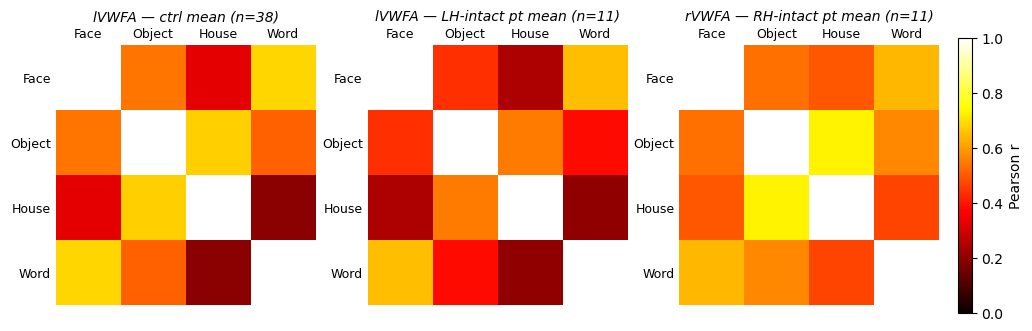

In [10]:
def plot_rdm_3panel(roi, fname):
    """1x3: ctrl lVWFA mean | LH-intact pt lVWFA mean | RH-intact pt rVWFA mean."""
    ctrl_lh, n_ctrl = mean_rdm(ctrl_pw, roi, 'l', ctrl_subs)

    lh_pt_subs = [s for s in otc_subs if pt_intact_hemi(s) == 'l']
    lh_pt_rdm, n_lh_pt = mean_rdm(pt_pw, roi, 'l', lh_pt_subs)

    rh_pt_subs = [s for s in otc_subs if pt_intact_hemi(s) == 'r']
    rh_pt_rdm, n_rh_pt = mean_rdm(pt_pw, roi, 'r', rh_pt_subs)

    short = roi.split('_')[-1]
    fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
    panels = [
        (ctrl_lh,   f'l{short} \u2014 ctrl mean (n={n_ctrl})'),
        (lh_pt_rdm, f'l{short} \u2014 LH-intact pt mean (n={n_lh_pt})'),
        (rh_pt_rdm, f'r{short} \u2014 RH-intact pt mean (n={n_rh_pt})'),
    ]
    last_im = None
    for ax, (M, ttl) in zip(axes, panels):
        im = ax.imshow(M, cmap='hot', vmin=0, vmax=1, aspect='equal')
        last_im = im
        ax.set_xticks(range(4)); ax.set_yticks(range(4))
        ax.set_xticklabels(['Face', 'Object', 'House', 'Word'], fontsize=9)
        ax.set_yticklabels(['Face', 'Object', 'House', 'Word'], fontsize=9)
        ax.xaxis.tick_top()
        ax.set_title(ttl, fontsize=10, style='italic', pad=18)
        ax.tick_params(length=0)
        for sp in ax.spines.values():
            sp.set_visible(False)
    fig.colorbar(last_im, ax=axes, fraction=0.030, pad=0.02, shrink=0.85, label='Pearson r')
    plt.savefig(FIG_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

plot_rdm_3panel('word_VWFA', 'liu_exact_fig3AB_VWFA_3panel.png')

## 9. Fig 3D — Per-ROI distinctiveness boxplot

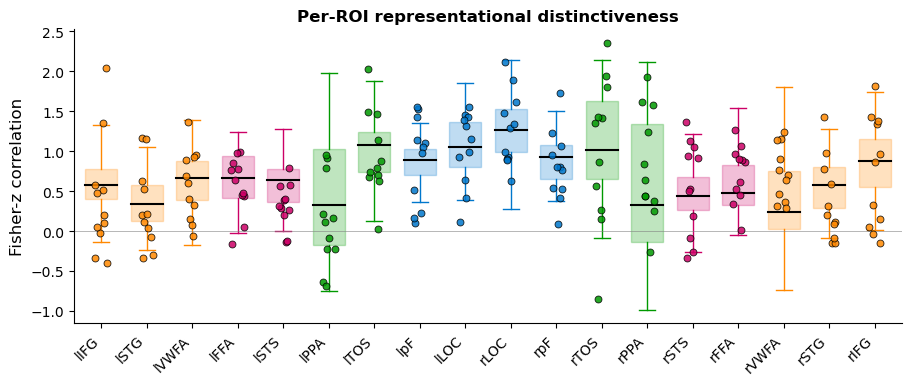

In [11]:
# Fig 3D — distinctiveness by ROI, face -> house -> object -> word
ROI_ORDER = [
    ('word_IFG',  'l'),  ('word_STG',  'l'),  ('word_VWFA', 'l'),
    ('face_FFA',  'l'),  ('face_STS',  'l'),
    ('house_PPA', 'l'),  ('house_TOS', 'l'),
    ('object_pF', 'l'),  ('object_LOC','l'),
    ('object_LOC','r'),  ('object_pF', 'r'),
    ('house_TOS', 'r'),  ('house_PPA', 'r'),
    ('face_STS',  'r'),  ('face_FFA',  'r'),
    ('word_VWFA', 'r'),  ('word_STG',  'r'),  ('word_IFG',  'r'),
]

def pt_panel_match(sub, hspec):
    pt_h = pt_intact_hemi(sub)
    if pt_h is None: return False, None
    return pt_h == hspec, pt_h

def roi_label(roi, hspec):
    s = roi.split('_')[-1]
    return f'{hspec}{s}'

ROI_CAT_COLOR = {
    'face_FFA':   '#cc0066', 'face_STS':   '#cc0066',
    'house_PPA':  '#009900', 'house_TOS':  '#009900',
    'object_pF':  '#0077cc', 'object_LOC': '#0077cc',
    'word_VWFA':  '#ff8800', 'word_STG':   '#ff8800',
    'word_IFG':   '#ff8800',
}

def get_distinct(df, sub, roi, hemi):
    m = df[(df['subject_id'] == sub) & (df['category'] == roi) & (df['hemi'] == hemi)]
    return m['liu_distinctiveness'].values[0] if len(m) else np.nan

n = len(ROI_ORDER)
fig, ax = plt.subplots(figsize=(max(9, n * 0.42), 4.2))
rng_d = np.random.RandomState(42)
JITTER = 0.15

for xi, (roi, hspec) in enumerate(ROI_ORDER):
    color = ROI_CAT_COLOR[roi]
    cvals = ctrl_le[(ctrl_le['category'] == roi) & (ctrl_le['hemi'] == hspec)] \
                   ['liu_distinctiveness'].dropna().values
    if len(cvals) == 0: continue
    ax.boxplot(cvals, positions=[xi], widths=0.7, patch_artist=True,
               showfliers=False,
               medianprops={'color': 'black', 'lw': 1.5},
               whiskerprops={'color': color}, capprops={'color': color},
               boxprops={'facecolor': color, 'alpha': 0.25, 'edgecolor': color})
    for sub in otc_subs:
        ok, pt_h = pt_panel_match(sub, hspec)
        if not ok: continue
        val = get_distinct(pt_le, sub, roi, pt_h)
        if np.isnan(val): continue
        ax.scatter(xi + rng_d.uniform(-JITTER, JITTER), val,
                   marker='o', s=25, zorder=5,
                   edgecolors='black', linewidth=0.6, facecolors=color, alpha=0.85)

ax.set_xticks(np.arange(n))
ax.set_xticklabels([roi_label(c, h) for c, h in ROI_ORDER],
                   rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Fisher-z correlation', fontsize=12)
ax.tick_params(axis='y', labelsize=10)
ax.axhline(0, color='gray', lw=0.4)
ax.set_title('Per-ROI representational distinctiveness',
             fontsize=12, fontweight='bold')
ax.set_xlim(-0.6, n - 0.4)
ax.margins(x=0.005)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.subplots_adjust(left=0.07, right=0.99, top=0.92, bottom=0.22)
plt.savefig(FIG_DIR / 'liu_exact_fig3D.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Fig 3E — Per-ROI Crawford t (with FDR)

Significant (raw alpha=.05):              25 / 198
Significant (within-ROI FDR-bh):       8 / 198
n_ctrl per ROI: min=37, max=38
Critical t (uncorrected, df=36): ±2.028



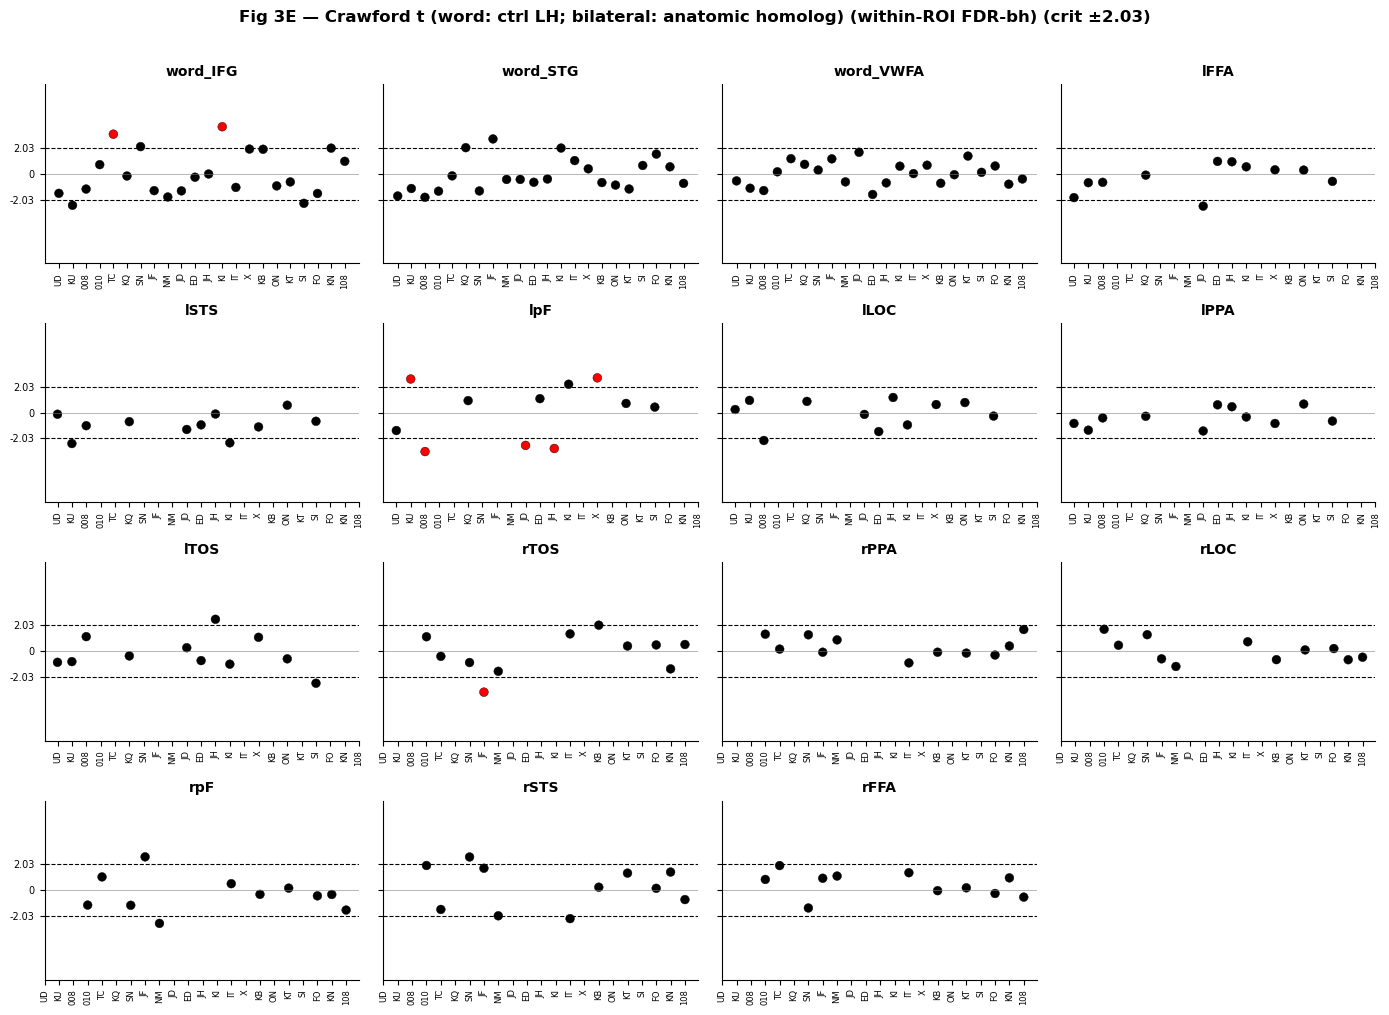

In [12]:
# Fig 3E — per-ROI Crawford t (with FDR option)
FDR_METHOD = 'bh'   # 'bh' or None

ROI_ORDER = [
    ('word_IFG',      'pooled'),
    ('word_STG',      'pooled'),
    ('word_VWFA',     'pooled'),
    ('face_FFA',      'l'),  ('face_STS', 'l'),
    ('object_pF',     'l'),  ('object_LOC','l'),
    ('house_PPA',     'l'),  ('house_TOS','l'),
    ('house_TOS',     'r'),  ('house_PPA','r'),
    ('object_LOC',    'r'),  ('object_pF','r'),
    ('face_STS',      'r'),  ('face_FFA', 'r'),
]

def ctrl_hemi(hspec):
    """Pooled (word) -> ctrl LH (Liu anchor); else -> hspec (anatomic homolog)."""
    return 'l' if hspec == 'pooled' else hspec

def pt_panel_match(sub, hspec):
    pt_h = pt_intact_hemi(sub)
    if pt_h is None: return False, None
    if hspec == 'pooled': return True, pt_h  # any patient, plotted at intact hemi
    return pt_h == hspec, pt_h

def roi_label(roi, hspec):
    s = roi.split('_')[-1]
    return f'word_{s}' if hspec == 'pooled' else f'{hspec}{s}'

def get_distinct(df, sub, roi, hemi):
    m = df[(df['subject_id'] == sub) & (df['category'] == roi) & (df['hemi'] == hemi)]
    return m['liu_distinctiveness'].values[0] if len(m) else np.nan

n = len(ROI_ORDER)
t_mat = np.full((n, len(otc_subs)), np.nan)
p_mat = np.full((n, len(otc_subs)), np.nan)
n_ctrls_roi = np.zeros(n, dtype=int)

for r, (roi, hspec) in enumerate(ROI_ORDER):
    ch = ctrl_hemi(hspec)
    cvals = ctrl_le[(ctrl_le['category'] == roi) & (ctrl_le['hemi'] == ch)]['liu_distinctiveness'].dropna().values
    n_ctrls_roi[r] = len(cvals)
    if len(cvals) < 3: continue
    for p_, sub in enumerate(otc_subs):
        ok, pt_h = pt_panel_match(sub, hspec)
        if not ok: continue
        val = get_distinct(pt_le, sub, roi, pt_h)
        if np.isnan(val): continue
        t_mat[r, p_], p_mat[r, p_] = crawford(val, cvals)

min_df = max(int(n_ctrls_roi[n_ctrls_roi > 0].min()) - 1, 1)
crit_3E = float(tdist.ppf(0.975, df=min_df))

if FDR_METHOD is not None:
    sig_mat = np.zeros_like(t_mat, dtype=bool)
    for r in range(n):
        sig_mat[r, :] = fdr_correct(p_mat[r, :], method=FDR_METHOD)
    n_raw = int((np.abs(t_mat) > crit_3E).sum())
    n_fdr = int(sig_mat.sum())
    print(f'Significant (raw alpha=.05):              {n_raw} / {(~np.isnan(t_mat)).sum()}')
    print(f'Significant (within-ROI FDR-{FDR_METHOD}):       {n_fdr} / {(~np.isnan(t_mat)).sum()}')
else:
    sig_mat = np.abs(t_mat) > crit_3E
    print(f'Significant (uncorrected): {int(sig_mat.sum())} / {(~np.isnan(t_mat)).sum()}')

print(f'n_ctrl per ROI: min={n_ctrls_roi[n_ctrls_roi>0].min()}, max={n_ctrls_roi.max()}')
print(f'Critical t (uncorrected, df={min_df}): ±{crit_3E:.3f}\n')

n_cols_3E = 4
n_rows_3E = int(np.ceil(n / n_cols_3E))
fig, axes = plt.subplots(n_rows_3E, n_cols_3E, figsize=(3.5 * n_cols_3E, 2.5 * n_rows_3E), sharey=True)
axes = axes.flatten()
pt_labels = [SUB_CODES.get(s, s.replace('sub-', '')) for s in otc_subs]

for r, (roi, hspec) in enumerate(ROI_ORDER):
    ax = axes[r]
    xs = np.arange(len(otc_subs))
    tv = t_mat[r]
    colors = ['red' if sig_mat[r, i] else 'black' for i in range(len(otc_subs))]
    ax.scatter(xs, tv, s=40, c=colors, edgecolors='k', linewidth=0.3)
    ax.axhline( crit_3E, color='k', lw=0.8, ls='--')
    ax.axhline(-crit_3E, color='k', lw=0.8, ls='--')
    ax.axhline(0, color='gray', lw=0.4)
    ax.set_ylim(-7, 7); ax.set_yticks([-crit_3E, 0, crit_3E])
    ax.set_yticklabels([f'{-crit_3E:.2f}', '0', f'{crit_3E:.2f}'], fontsize=7)
    ax.set_xticks(xs); ax.set_xticklabels(pt_labels, rotation=90, fontsize=6)
    ax.set_title(roi_label(roi, hspec), fontsize=10, fontweight='bold')

for r in range(n, len(axes)):
    axes[r].axis('off')

suffix = f' (within-ROI FDR-{FDR_METHOD})' if FDR_METHOD else ' (uncorrected)'
plt.suptitle(f'Fig 3E — Crawford t (word: ctrl LH; bilateral: anatomic homolog){suffix} (crit ±{crit_3E:.2f})',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'liu_exact_fig3E.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Sum-selectivity violin (per category × intact hemi)

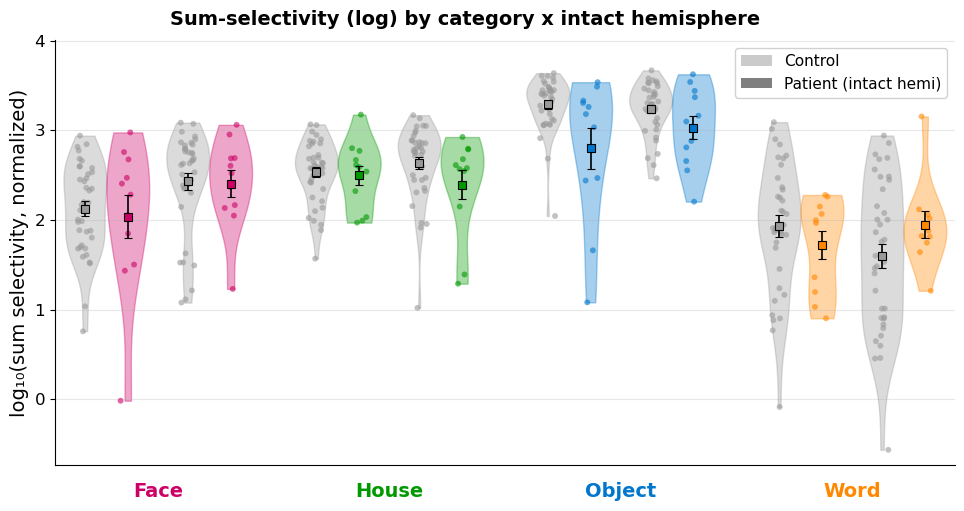

In [13]:
# Sum-selectivity violin: per category x intact hemi
CAT_SUBROIS = {
    'face':   ['face_FFA', 'face_STS'],
    'house':  ['house_PPA', 'house_TOS'],
    'object': ['object_LOC', 'object_pF'],
    'word':   ['word_VWFA', 'word_STG', 'word_pSTG_liu'],
}
CAT_COLORS_SS = {'face': '#cc0066', 'house': '#009900',
                 'object': '#0077cc', 'word': '#ff8800'}
CTRL_COLOR = '#999999'

def collapse_log_sumsel(df, subject, category, hemi):
    sub = df[(df['subject_id'] == subject) &
             (df['category'].isin(CAT_SUBROIS[category])) &
             (df['hemi'] == hemi)].drop_duplicates(subset=['subject_id','category','hemi'])
    vals = sub['sum_selec_norm'].dropna().values
    vals = vals[vals > 0]
    return np.mean(np.log10(vals)) if len(vals) else np.nan

def build_table(df, subjects):
    rows = []
    for s in subjects:
        for cat in CAT_SUBROIS:
            for h in ('l', 'r'):
                v = collapse_log_sumsel(df, s, cat, h)
                if not np.isnan(v):
                    rows.append({'subject_id': s, 'category': cat, 'hemi': h, 'val': v})
    return pd.DataFrame(rows)

ctrl_ss = build_table(ctrl_le, ctrl_subs)
pt_ss   = build_table(pt_le,   otc_subs)

intact_lookup = dict(zip(pt_le['subject_id'], pt_le['intact_hemi']))
pt_ss['intact_hemi'] = pt_ss['subject_id'].map(intact_lookup)
pt_ss = pt_ss[
    ((pt_ss['intact_hemi'] == 'left')  & (pt_ss['hemi'] == 'l')) |
    ((pt_ss['intact_hemi'] == 'right') & (pt_ss['hemi'] == 'r'))
]

CATS_PANEL = ['face', 'house', 'object', 'word']
INTRA, INTER, CAT_GAP = 0.5, 0.7, 1.0
positions_within = [0.0, INTRA, INTRA + INTER, 2*INTRA + INTER]
cat_width = positions_within[-1]

fig, ax = plt.subplots(figsize=(10, 5))
RNG = np.random.RandomState(42)
cat_centers = []

for ci, cat in enumerate(CATS_PANEL):
    cat_color = CAT_COLORS_SS[cat]
    base = ci * (cat_width + CAT_GAP)
    positions = [base + p for p in positions_within]
    cat_centers.append(np.mean(positions))

    cl = ctrl_ss[(ctrl_ss['category'] == cat) & (ctrl_ss['hemi'] == 'l')]['val'].values
    cr = ctrl_ss[(ctrl_ss['category'] == cat) & (ctrl_ss['hemi'] == 'r')]['val'].values
    pl = pt_ss[(pt_ss['category'] == cat) & (pt_ss['hemi'] == 'l')]['val'].values
    pr = pt_ss[(pt_ss['category'] == cat) & (pt_ss['hemi'] == 'r')]['val'].values

    groups = [
        (cl, positions[0], CTRL_COLOR),
        (pl, positions[1], cat_color),
        (cr, positions[2], CTRL_COLOR),
        (pr, positions[3], cat_color),
    ]

    for vals, pos, col in groups:
        vals = vals[~np.isnan(vals)]
        if len(vals) == 0: continue
        if len(vals) >= 2:
            parts = ax.violinplot([vals], positions=[pos], widths=0.5,
                                  showmeans=False, showmedians=False, showextrema=False)
            for b in parts['bodies']:
                b.set_facecolor(col); b.set_alpha(0.35); b.set_edgecolor(col)
        jit = RNG.uniform(-0.09, 0.09, len(vals))
        ax.scatter(np.full(len(vals), pos) + jit, vals,
                   color=col, alpha=0.6, s=18, edgecolors='none', zorder=3)
        ax.errorbar(pos, np.mean(vals),
                    yerr=np.std(vals)/np.sqrt(max(len(vals), 1)),
                    color='black', marker='s', markersize=6,
                    markerfacecolor=col, markeredgecolor='black',
                    markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

ax.set_xticks([])
ax.set_ylabel('log₁₀(sum selectivity, normalized)', fontsize=14)
ax.tick_params(axis='y', labelsize=12)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for cat, center in zip(CATS_PANEL, cat_centers):
    ax.text(center, -0.04, cat.title(), fontsize=14, fontweight='bold',
            color=CAT_COLORS_SS[cat], ha='center', va='top',
            transform=ax.get_xaxis_transform())

total_width = len(CATS_PANEL) * cat_width + (len(CATS_PANEL) - 1) * CAT_GAP
ax.set_xlim(-0.35, total_width + 0.35)
ax.margins(x=0.005)

all_vals = np.concatenate([ctrl_ss['val'].dropna().values, pt_ss['val'].dropna().values])
ymin, ymax = np.nanmin(all_vals), np.nanmax(all_vals)
yrange = ymax - ymin
ax.set_ylim(ymin - 0.04 * yrange, ymax + 0.08 * yrange)

legend_elements = [
    Patch(facecolor=CTRL_COLOR, alpha=0.5, label='Control'),
    Patch(facecolor='black', alpha=0.5, label='Patient (intact hemi)'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11,
          frameon=True, framealpha=0.9)

plt.suptitle('Sum-selectivity (log) by category x intact hemisphere',
             fontsize=14, fontweight='bold', y=0.99)
plt.subplots_adjust(bottom=0.08, top=0.93, left=0.09, right=0.99)
plt.savefig(FIG_DIR / 'liu_exact_sum_selectivity.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Sum-selectivity — per-ROI permutation test

Structural analog of the per-ROI distance permutation. Tests group-mean log₁₀(sum_selec_norm) per ROI × hemi.

In [14]:
# Sum-selectivity: permutation test on group mean difference per ROI x hemi
# Mirrors the distance permutation. log10(sum_selec_norm) per subject.
N_PERM = 10000
rng_s = np.random.RandomState(42)
ALL_ROIS_FLAT = ['face_FFA','face_STS','house_PPA','house_TOS',
                 'object_LOC','object_pF','word_VWFA','word_STG',
                 'word_pSTG_liu','word_IFG']

print(f'{"Group":12s} {"ROI":18s} {"ctrl":>8s} {"pt":>8s} {"Δ":>8s} {"p_perm":>8s}')
print('-'*65)
for intact, label in [('l','LH (R-res)'),('r','RH (L-res)')]:
    pt_subs_h = [s for s in otc_subs if pt_intact_hemi(s)==intact]
    for roi in ALL_ROIS_FLAT:
        ct = ctrl_le[(ctrl_le['category']==roi) & (ctrl_le['hemi']==intact)]['sum_selec_norm'].dropna().values
        ct = ct[ct > 0]
        ct = np.log10(ct)
        pt = pt_le[(pt_le['subject_id'].isin(pt_subs_h)) & (pt_le['category']==roi) &
                   (pt_le['hemi']==intact)]['sum_selec_norm'].dropna().values
        pt = pt[pt > 0]
        pt = np.log10(pt)
        if len(ct)<3 or len(pt)<2: continue
        obs = pt.mean() - ct.mean()
        pool = np.concatenate([ct, pt])
        n_pt = len(pt)
        null = np.empty(N_PERM)
        for i in range(N_PERM):
            perm = rng_s.permutation(pool)
            null[i] = perm[:n_pt].mean() - perm[n_pt:].mean()
        p = (np.abs(null) >= abs(obs)).mean()
        flag = '*' if p<0.05 else ('†' if p<0.1 else '')
        print(f'{label:12s} {roi:18s} {ct.mean():8.2f} {pt.mean():8.2f} {obs:+8.2f} {p:8.4f} {flag}')

Group        ROI                    ctrl       pt        Δ   p_perm
-----------------------------------------------------------------
LH (R-res)   face_FFA               2.41     2.35    -0.06   0.7396 
LH (R-res)   face_STS               1.84     1.72    -0.12   0.6956 
LH (R-res)   house_PPA              2.73     2.63    -0.10   0.4296 
LH (R-res)   house_TOS              2.33     2.37    +0.03   0.8571 
LH (R-res)   object_LOC             3.23     2.80    -0.43   0.0017 *
LH (R-res)   object_pF              3.35     2.80    -0.55   0.0120 *
LH (R-res)   word_VWFA              2.26     2.33    +0.07   0.8065 
LH (R-res)   word_STG               1.51     1.55    +0.04   0.8965 
LH (R-res)   word_pSTG_liu          1.69     1.39    -0.30   0.3689 
LH (R-res)   word_IFG               1.30     1.51    +0.21   0.5613 
RH (L-res)   face_FFA               2.62     2.55    -0.08   0.6907 
RH (L-res)   face_STS               2.27     2.27    -0.00   0.9953 
RH (L-res)   house_PPA              

In [15]:
# Volume and mean_act: per-ROI permutation tests (analog of sum-sel perm).
# Volume tested on log10 (count-like); mean_act tested raw (continuous).
N_PERM = 10000
ALL_ROIS_FLAT = ['face_FFA','face_STS','house_PPA','house_TOS',
                 'object_LOC','object_pF','word_VWFA','word_STG',
                 'word_pSTG_liu','word_IFG']

def run_perm(metric_name, column, transform=None, seed=42):
    rng = np.random.RandomState(seed)
    print(f'\n=== {metric_name} ===')
    print(f'{"Group":12s} {"ROI":18s} {"ctrl":>8s} {"pt":>8s} {"Δ":>8s} {"p_perm":>8s}')
    print('-'*65)
    for intact, label in [('l','LH (R-res)'),('r','RH (L-res)')]:
        pt_subs_h = [s for s in otc_subs if pt_intact_hemi(s)==intact]
        for roi in ALL_ROIS_FLAT:
            ct = ctrl_le[(ctrl_le['category']==roi) & (ctrl_le['hemi']==intact)][column].dropna().values
            pt = pt_le[(pt_le['subject_id'].isin(pt_subs_h)) & (pt_le['category']==roi) &
                       (pt_le['hemi']==intact)][column].dropna().values
            if transform == 'log10':
                ct = np.log10(ct[ct > 0])
                pt = np.log10(pt[pt > 0])
            if len(ct)<3 or len(pt)<2: continue
            obs = pt.mean() - ct.mean()
            pool = np.concatenate([ct, pt])
            n_pt = len(pt)
            null = np.empty(N_PERM)
            for i in range(N_PERM):
                perm = rng.permutation(pool)
                null[i] = perm[:n_pt].mean() - perm[n_pt:].mean()
            p = (np.abs(null) >= abs(obs)).mean()
            flag = '*' if p<0.05 else ('†' if p<0.1 else '')
            print(f'{label:12s} {roi:18s} {ct.mean():8.2f} {pt.mean():8.2f} {obs:+8.2f} {p:8.4f} {flag}')

run_perm('Volume (log10)', 'volume', transform='log10')
run_perm('Mean activation (raw)', 'mean_act', transform=None)


=== Volume (log10) ===
Group        ROI                    ctrl       pt        Δ   p_perm
-----------------------------------------------------------------
LH (R-res)   face_FFA               2.77     2.71    -0.06   0.6919 
LH (R-res)   face_STS               2.40     2.25    -0.15   0.5934 
LH (R-res)   house_PPA              3.30     3.22    -0.08   0.4460 
LH (R-res)   house_TOS              3.41     3.41    -0.00   0.9951 
LH (R-res)   object_LOC             4.18     3.79    -0.39   0.0011 *
LH (R-res)   object_pF              3.34     2.85    -0.49   0.0115 *
LH (R-res)   word_VWFA              2.77     2.79    +0.02   0.9343 
LH (R-res)   word_STG               1.94     1.97    +0.02   0.9411 
LH (R-res)   word_pSTG_liu          2.02     1.71    -0.31   0.3340 
LH (R-res)   word_IFG               1.80     1.98    +0.18   0.6106 
RH (L-res)   face_FFA               2.97     2.86    -0.11   0.4994 
RH (L-res)   face_STS               2.88     2.87    -0.01   0.9712 
RH (L-res)  

In [ ]:
#!SECTION
needs REVIEW - 
###
import numpy as np
import pandas as pd

# Constants
SEED = 42
N_PERM = 10000
PRIMARY_ROIS = ['face_FFA', 'house_PPA', 'object_LOC', 'word_VWFA']

# Helper: extract values for a measure
def get_vals(df, subs, roi, hemi, col, log10=False):
    sub = df[(df['subject_id'].isin(subs)) & (df['category']==roi) & (df['hemi']==hemi)]
    v = sub[col].dropna().values.astype(float)
    if log10: v = np.log10(v[v > 0])
    return v

# Helper: patient intact hemi
def pt_intact_hemi(s):
    r = pt_le[pt_le['subject_id']==s]['intact_hemi']
    if not len(r): return None
    return 'l' if r.iloc[0] == 'left' else 'r'

# Permutation test
def two_sample_perm(a, b, n_perm=N_PERM, seed=SEED):
    a, b = np.asarray(a, float), np.asarray(b, float)
    a, b = a[~np.isnan(a)], b[~np.isnan(b)]
    if len(a) < 2 or len(b) < 2: return np.nan, np.nan
    obs = b.mean() - a.mean()
    pool = np.concatenate([a, b]); n_b = len(b)
    rng = np.random.RandomState(seed)
    null = np.empty(n_perm)
    for i in range(n_perm):
        perm = rng.permutation(pool)
        null[i] = perm[:n_b].mean() - perm[n_b:].mean()
    return obs, (np.abs(null) >= abs(obs)).mean()

# Patient subsets by intact hemisphere
pt_LH = [s for s in otc_subs if pt_intact_hemi(s) == 'l']
pt_RH = [s for s in otc_subs if pt_intact_hemi(s) == 'r']

# Control centroids per ROI × hemi (for distance metric)
centroids = {}
for roi in PRIMARY_ROIS:
    for h in ('l', 'r'):
        c = ctrl_le[(ctrl_le['category']==roi) & (ctrl_le['hemi']==h)][['peak_x_native','peak_y_native']].dropna()
        centroids[(roi, h)] = (c['peak_x_native'].mean(), c['peak_y_native'].mean()) if len(c) else (np.nan, np.nan)

def get_distance(df, sub, roi, hemi):
    r = df[(df['subject_id']==sub) & (df['category']==roi) & (df['hemi']==hemi)]
    if not len(r): return np.nan
    cx, cy = centroids[(roi, hemi)]
    if np.isnan(cx) or np.isnan(r['peak_x_native'].iloc[0]): return np.nan
    return float(np.sqrt((r['peak_x_native'].iloc[0]-cx)**2 + (r['peak_y_native'].iloc[0]-cy)**2))

# Analysis
print('=== Δ-based LH-intact vs RH-intact (Δ = patient − same-hemi control mean) ===\n')
print(f'{"Measure":12s} {"ROI":12s} {"LH-Δ":>9s} {"RH-Δ":>9s} {"diff":>9s} {"p_perm":>8s}')
print('-' * 65)
all_rows = []

for measure_name, col, log10 in [('sum_sel', 'sum_selec_norm', True),
                                  ('distance_2d', None, False)]:
    for roi in PRIMARY_ROIS:
        if col is None:  # distance
            ctrl_L = np.array([get_distance(ctrl_le, s, roi, 'l') for s in ctrl_subs])
            ctrl_R = np.array([get_distance(ctrl_le, s, roi, 'r') for s in ctrl_subs])
            ct_L_mean = np.nanmean(ctrl_L)
            ct_R_mean = np.nanmean(ctrl_R)
            d_LH = np.array([get_distance(pt_le, s, roi, 'l') for s in pt_LH]) - ct_L_mean
            d_RH = np.array([get_distance(pt_le, s, roi, 'r') for s in pt_RH]) - ct_R_mean
        else:
            ct_L_mean = get_vals(ctrl_le, ctrl_subs, roi, 'l', col, log10=log10).mean()
            ct_R_mean = get_vals(ctrl_le, ctrl_subs, roi, 'r', col, log10=log10).mean()
            pt_L = get_vals(pt_le, pt_LH, roi, 'l', col, log10=log10)
            pt_R = get_vals(pt_le, pt_RH, roi, 'r', col, log10=log10)
            d_LH = pt_L - ct_L_mean
            d_RH = pt_R - ct_R_mean
        d_LH_clean = d_LH[~np.isnan(d_LH)]
        d_RH_clean = d_RH[~np.isnan(d_RH)]
        diff, p = two_sample_perm(d_LH_clean, d_RH_clean)
        flag = '*' if (not np.isnan(p) and p < 0.05) else ('†' if (not np.isnan(p) and p < 0.10) else '')
        print(f'{measure_name:12s} {roi:12s} {d_LH_clean.mean():>+9.3f} {d_RH_clean.mean():>+9.3f} '
              f'{diff:>+9.3f} {p:>8.4f} {flag}')
        all_rows.append({'measure': measure_name, 'roi': roi,
                         'lh_delta': d_LH_clean.mean(), 'rh_delta': d_RH_clean.mean(),
                         'diff': diff, 'p_perm': p,
                         'n_LH': len(d_LH_clean), 'n_RH': len(d_RH_clean)})
    print()

pd.DataFrame(all_rows).to_csv(FIG_DIR / 'pt_group_delta_sumsel_distance.csv', index=False)

=== Δ-based LH-intact vs RH-intact (Δ = patient − same-hemi control mean) ===

Measure      ROI               LH-Δ      RH-Δ      diff   p_perm
-----------------------------------------------------------------
sum_sel      face_FFA        -0.060    -0.076    -0.016   0.9671 
sum_sel      house_PPA       -0.101    -0.124    -0.023   0.9097 
sum_sel      object_LOC      -0.427    -0.100    +0.328   0.1769 
sum_sel      word_VWFA       +0.070    +0.027    -0.043   0.9069 

distance_2d  face_FFA        +0.895    +0.457    -0.438   0.8924 
distance_2d  house_PPA       +1.956    +3.792    +1.837   0.6868 
distance_2d  object_LOC      -0.386    +2.628    +3.014   0.3190 
distance_2d  word_VWFA       +3.842    +0.865    -2.976   0.5044 

